## **TYPES OF MCP SERVERS**

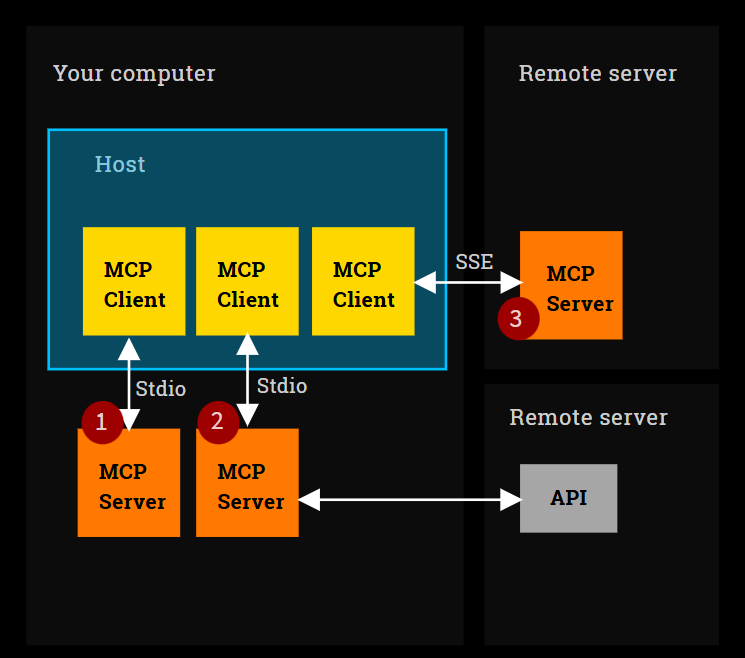

In [1]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace
from agents.mcp import MCPServerStdio
import os
from IPython.display import Markdown, display
from datetime import datetime
load_dotenv(override=True)

True

### **01. Runs locally, everything local**

Example: a knowledge-graph based memory.

It's a persistent memory store of entities, observations about them, and relationships between them.

https://github.com/modelcontextprotocol/servers/tree/main/src/memory


In [2]:
mkdir -p /mnt/d/study_2/MCP_Project/memory

In [3]:
params = {"command": "npx","args": ["-y", "mcp-memory-libsql"],"env": {"LIBSQL_URL": "file:./memory/prateek.db"}}

async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as server:
    mcp_tools = await server.list_tools()

mcp_tools

[Tool(name='create_entities', title='Create new entities with observations', description='Create new entities with observations', inputSchema={'type': 'object', 'properties': {'entities': {'type': 'array', 'items': {'type': 'object', 'properties': {'name': {'type': 'string', 'maxLength': 256}, 'entityType': {'type': 'string', 'maxLength': 256}, 'observations': {'type': 'array', 'items': {'type': 'string', 'maxLength': 4096}, 'maxItems': 100}}, 'required': ['name', 'entityType', 'observations']}, 'maxItems': 50}}, 'required': ['entities'], '$schema': 'http://json-schema.org/draft-07/schema#'}, outputSchema=None, icons=None, annotations=ToolAnnotations(title=None, readOnlyHint=False, destructiveHint=None, idempotentHint=True, openWorldHint=None), meta=None, execution=None),
 Tool(name='search_nodes', title='Search for entities and their relations using text search with relevance ranking', description='Search for entities and their relations using text search with relevance ranking', inpu

In [4]:
instructions = """You use your entity tools as persistent memory to store and recall 
information about your conversations. Always save important facts and retrieve them when relevant."""

request = """My name is Prateek. I am an AI/ML Engineer 
I am currently exporing MCP (Model Context Protocol). 

Here is what I have learned so far:
- MCP is a standard protocol for connecting AI agents with tools
- There are two sides: MCP Server (has the tools) and MCP Client (uses the tools)
- Transport mechanisms: Stdio (local) and HTTP (remote)
- Pre-built servers exist: mcp-server-fetch, playwright, filesystem
- I built a company research agent using fetch and filesystem MCP servers
- async/await is used because MCP servers are separate processes and communication takes time
- @function_tool decorator turns a Python function into an agent tool

Please store all of this information about me and my learning progress."""

model = "gpt-4.1-mini"

In [5]:
async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as mcp_server:
    agent = Agent(name="agent", instructions=instructions, model=model, mcp_servers=[mcp_server])
    with trace("information"):
        result = await Runner.run(agent, request)
    display(Markdown(result.final_output))

I have stored the information about you, Prateek, including your profession as an AI/ML Engineer and your current learning progress on MCP (Model Context Protocol) with all the details you provided. If you want to continue learning or want help with anything related to MCP or AI/ML, just let me know!

In [6]:
async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as mcp_server:
    agent = Agent(name="agent", instructions=instructions, model=model, mcp_servers=[mcp_server])
    with trace("conversation"):
        result = await Runner.run(agent, "hey its Prateek again, do you remember me?")
    display(Markdown(result.final_output))

Hi Prateek! Yes, I remember you. You're an AI/ML Engineer currently exploring MCP (Model Context Protocol). You've learned about MCP being a protocol for connecting AI agents with tools, the two sides of MCP (Server and Client), transport mechanisms like Stdio and HTTP, and you've built a company research agent using fetch and filesystem MCP servers. How can I assist you today?

###  **02. Runs locally, calls a web service**

In [ ]:
env = {"BRAVE_API_KEY": os.getenv("BRAVE_API_KEY")}
params = {"command": "npx", "args": ["-y", "@modelcontextprotocol/server-brave-search"], "env": env}

async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as server:
    mcp_tools = await server.list_tools()

mcp_tools

In [ ]:
instructions = "You are able to search the web for information and briefly summarize the takeaways."
request = f"Please research the latest news on Amazon stock price and briefly summarize its outlook. \
For context, the current date is {datetime.now().strftime('%Y-%m-%d')}"
model = "gpt-4o-mini"

In [ ]:
async with MCPServerStdio(params=params, client_session_timeout_seconds=30) as mcp_server:
    agent = Agent(name="agent", instructions=instructions, model=model, mcp_servers=[mcp_server])
    with trace("conversation"):
        result = await Runner.run(agent, request)
    display(Markdown(result.final_output))

### **02.01 NEW : Exploring polygon.io**

**Steps:**
1. Please sign up for polygon.io (top right)  
2. Once signed in, please select "Keys" in the left hand navigation
3. Press the blue "New Key" button
4. Copy the key name
5. Edit your .env file and add the row:

`POLYGON_API_KEY=xxxx`

In [7]:
load_dotenv(override=True)
polygon_api_key = os.getenv("POLYGON_API_KEY")
if not polygon_api_key:
    print("POLYGON_API_KEY is not set")

### **03. Creating an MCP Server, just for practice**

In [14]:
params = {"command": "uv", "args": ["run", "utils/market_server.py"]}
async with MCPServerStdio(params=params, client_session_timeout_seconds=60) as server:
    mcp_tools = await server.list_tools()
mcp_tools

[Tool(name='lookup_share_price', title=None, description='This tool provides the current price of the given stock symbol.\n\n    Args:\n        symbol: the symbol of the stock\n    ', inputSchema={'properties': {'symbol': {'title': 'Symbol', 'type': 'string'}}, 'required': ['symbol'], 'title': 'lookup_share_priceArguments', 'type': 'object'}, outputSchema={'properties': {'result': {'title': 'Result', 'type': 'number'}}, 'required': ['result'], 'title': 'lookup_share_priceOutput', 'type': 'object'}, icons=None, annotations=None, meta=None, execution=None)]

In [15]:
instructions = "You answer questions about the stock market."
request = "What's the share price of Apple?"
model = "gpt-4.1-mini"

async with MCPServerStdio(params=params, client_session_timeout_seconds=60) as mcp_server:
    agent = Agent(name="agent", instructions=instructions, model=model, mcp_servers=[mcp_server])
    with trace("conversation"):
        result = await Runner.run(agent, request)
    display(Markdown(result.final_output))

The current share price of Apple (AAPL) is $291.13.